In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
from trainingTools import make_flow
import helper_functions as hf
from functools import partial
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import json
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
import h5py
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')
import json
from samples import signal_merged_dir, signal_map
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from scipy.stats import boxcox
import os

In [3]:
with h5py.File("lossEvals/BKG.h5","r") as f:
    l_bkg = f["BKG_mjjFlat"][()]
with h5py.File("lossEvals/DATA.h5","r") as f:
    l_dat = f["BKG_mjjFlat"][()]

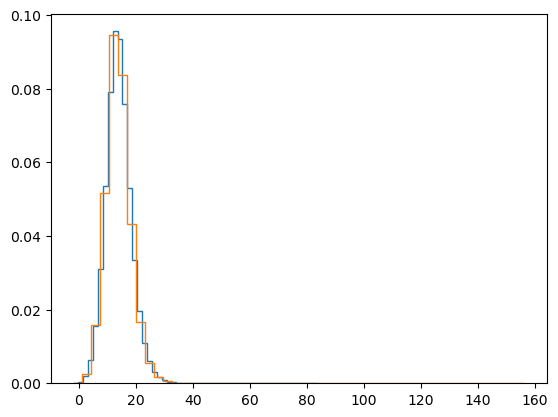

In [4]:
h1 = plt.hist(l_bkg,bins=50,histtype='step',density=True)
h1 = plt.hist(l_dat,bins=50,histtype='step',density=True)

In [5]:
with open(f"combined_trainings/BKG_mjjFlat/flow_kwargs.json","r") as f:
    kw = json.load(f)
variables = kw['variables']
flow = make_flow(len(variables),kw).to(device)
flow.load_state_dict(torch.load(f"combined_trainings/BKG_mjjFlat/BKG_mjjFlat.pt"))
bkg_test = hf.loadData("BKG",variables,nMax=-1,dEta_cut=-1,mode="test",sideband=False)
bkg_test = (bkg_test-bkg_test.mean(axis=0))/bkg_test.std(axis=0)

with torch.no_grad():
    n = bkg_test.shape[0]
    num = n//200000
    split = np.array_split(np.arange(n),num)
    l_test = []
    for sp in split:
        l_test.append(-flow.log_prob(torch.tensor(bkg_test[sp],device=device)).detach().cpu().numpy())
l_test = np.concatenate(l_test,axis=0)

100%|██████████| 80/80 [00:06<00:00, 11.46it/s]


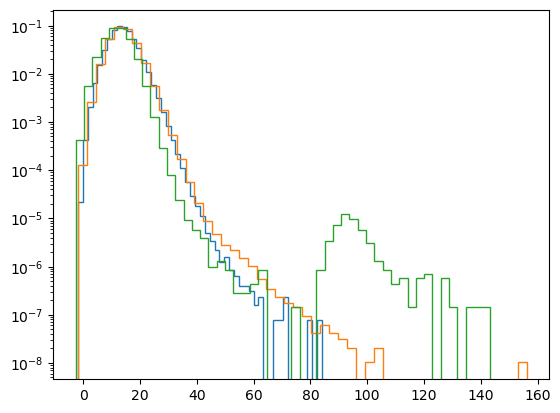

In [6]:
h1 = plt.hist(l_bkg,bins=50,histtype='step',density=True)
h1 = plt.hist(l_dat,bins=50,histtype='step',density=True)
h1 = plt.hist(l_test,bins=50,histtype='step',density=True)
plt.yscale('log')

In [13]:
print(l_bkg.mean(),l_test.mean())

13.980264 12.004561


In [2]:
s = "XYY3000_Y170_Yp170"

# get bkg stuff

In [3]:
bkg_file = "lossEvals/BKG.h5"
with h5py.File(bkg_file,"r") as fin:
    l_bkg = fin[s][()]
    m_bkg = fin["mjj"][()]
pca = PCA().fit(np.concatenate((m_bkg.reshape(-1,1),l_bkg.reshape(-1,1)),axis=1))
lmax = -999999
lmin = 999999
files = ["lossEvals/BKG.h5"]+["lossEvals/"+f for f in os.listdir("lossEvals/") if f != "BKG.h5" and ".h5" in f]
systematics = ["JES_up","JES_down","JER_up","JER_down","JMS_up","JMS_down","JMR_up","JMR_down"]
for sf in files:
    with h5py.File(sf,"r") as fin:
        mjj = fin["mjj"][()]
        possible = [s] + [f"{s}_{r}" for r in systematics]
        relevant = [k for k in list(fin.keys()) if k in possible]
        for r in relevant:
            lss = fin[r][()]
            new = np.dot(np.concatenate((mjj.reshape(-1,1),lss.reshape(-1,1)),axis=1),pca.components_.T)[:,1]
            if new.max()>lmax:
                lmax = new.max()
            if new.min()<lmin:
                lmin=new.min()
new_bkg = np.dot(np.concatenate((m_bkg.reshape(-1,1),l_bkg.reshape(-1,1)),axis=1),pca.components_.T)[:,1]
y_bkg = 1+new_bkg-lmin # shift to make positive
y_bkg,lam = boxcox(y_bkg)
bmean = y_bkg.mean()
bsd = y_bkg.std()
y_bkg = (y_bkg-bmean)/bsd

/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/numpy/core/_methods.py:205: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


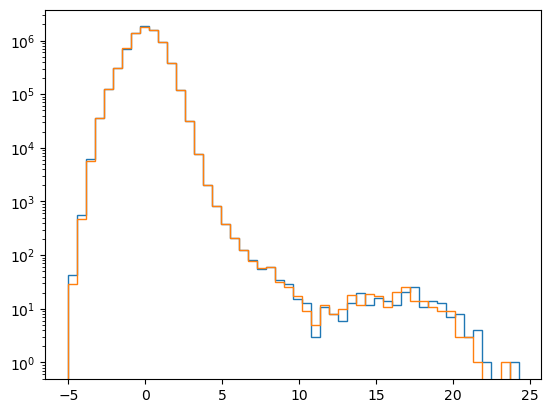

In [4]:
with h5py.File("lossEvals_pcaDecorr_boxCox/BKG.h5","r") as fin:
    ltest = fin[s][()]
h1,bins,_ = plt.hist(ltest,bins=50,histtype='step')
h2 = plt.hist(y_bkg,bins=bins,histtype='step')
plt.yscale('log')

# load signal data and flow

In [6]:
#flow = torch.load(f"combined_trainings/{s}/{s}.pt").to(device)
with open(f"combined_trainings/{s}/flow_kwargs.json","r") as f:
    kw = json.load(f)
variables = kw['variables']
flow = make_flow(len(variables),kw).to(device)
flow.load_state_dict(torch.load(f"combined_trainings/{s}/{s}.pt"))
file = signal_merged_dir+signal_map[s]
data = hf.loadVariables(file,variables,dEta_cut=1.3,mode="all")
data_mjj = hf.loadVariables(file,["mjj"],dEta_cut=1.3,mode="all")[:,0]

means = []
stds = []
ref_file = "meanStd.h5" # no dEta cut
with h5py.File(f"input_h5s/BKG/{ref_file}","r") as f:
    for v in variables:
        means.append(f[v+"_mean"][()])
        stds.append(f[v+"_std"][()])
means = np.array(means)
stds = np.array(stds)

data_norm = (data-means)/stds

In [13]:
with h5py.File("XYY3000_Y170_Yp170_old.h5","r") as fin:
    losses_old = fin[s][()]
with h5py.File("XYY3000_Y170_Yp170_new.h5","r") as fin:
    losses_new = fin[s][()]
with torch.no_grad():
    losses_data = -flow.log_prob(torch.tensor(data,device=device)).detach().cpu().numpy()
    losses_data_norm = -flow.log_prob(torch.tensor(data_norm,device=device)).detach().cpu().numpy()
    samples = flow.sample(100000).detach().cpu().numpy()

In [15]:
# correct losses just calculated
losses_data = np.dot(np.concatenate((data_mjj.reshape(-1,1),losses_data.reshape(-1,1)),axis=1),pca.components_.T)[:,1]
losses_data = boxcox(1 + losses_data - lmin,lmbda=lam)
losses_data = (losses_data-bmean)/bsd
losses_data_norm = np.dot(np.concatenate((data_mjj.reshape(-1,1),losses_data_norm.reshape(-1,1)),axis=1),pca.components_.T)[:,1]
losses_data_norm = boxcox(1 + losses_data_norm - lmin,lmbda=lam)
losses_data_norm = (losses_data_norm-bmean)/bsd

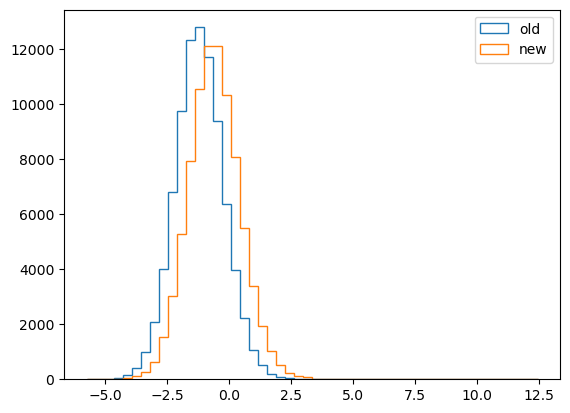

In [17]:
h1,bins,_ = plt.hist(losses_old,bins=50,histtype='step',label='old')
h2,bins,_ = plt.hist(losses_new,bins=bins,histtype='step',label='new')
#h3,bins,_ = plt.hist(losses_data,bins=50,histtype='step',label='data unnorm')
#h4,bins,_ = plt.hist(losses_data_norm,bins=bins,histtype='step',label='data norm')
plt.legend()

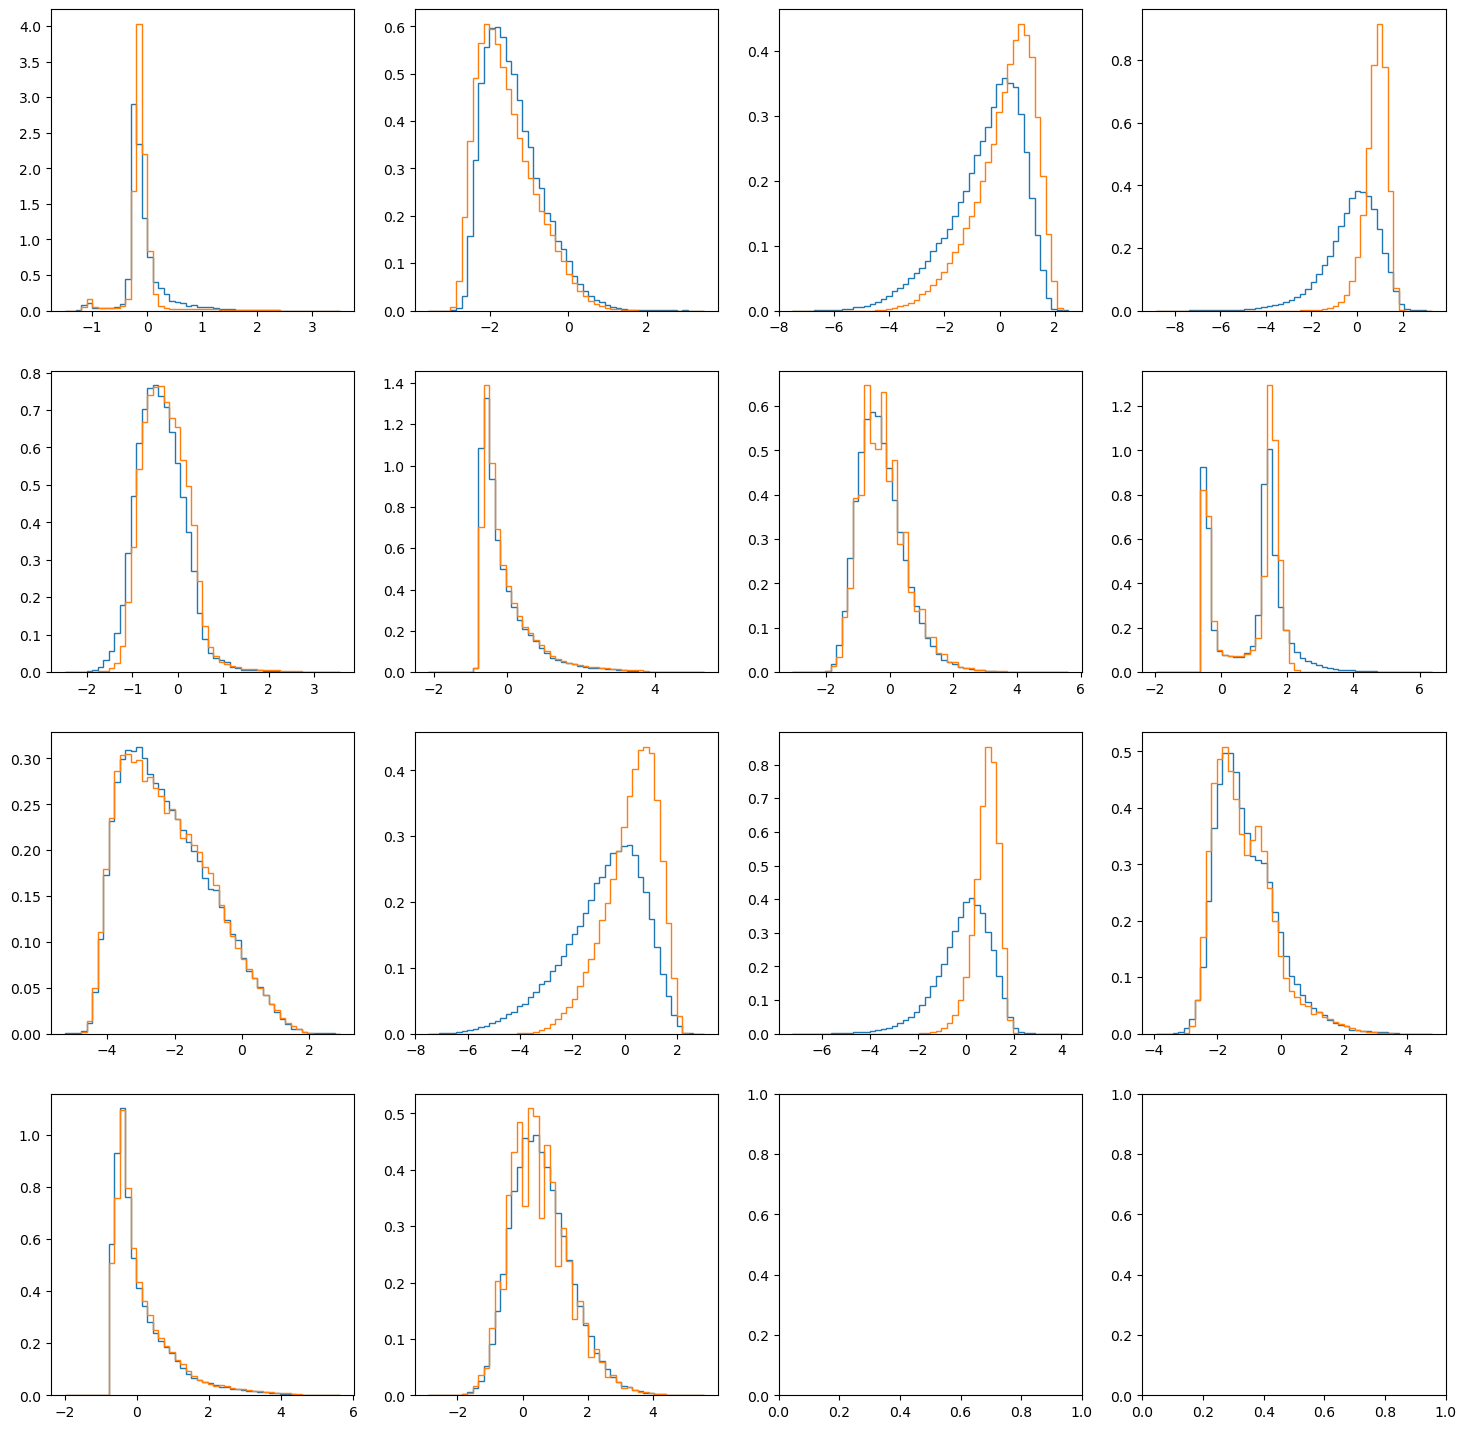

In [18]:
fig,axes = plt.subplots(4,4,figsize=(18,18))
t = axes.flatten()
for i in range(samples.shape[1]):
    plt.sca(t[i])
    h2,bins,_ = plt.hist(samples[:,i],bins=50,histtype='step',density=True)
    h1 = plt.hist(data_norm[:,i],bins=bins,histtype='step',density=True)


# BKG samples

In [3]:
with open(f"combined_trainings/BKG_mjjFlat/flow_kwargs.json","r") as f:
    kw = json.load(f)
variables = kw['variables']
means = []
stds = []
ref_file = "meanStd.h5" # no dEta cut
with h5py.File(f"input_h5s/BKG/{ref_file}","r") as f:
    for v in variables:
        means.append(f[v+"_mean"][()])
        stds.append(f[v+"_std"][()])
means = np.array(means)
stds = np.array(stds)

In [15]:
with h5py.File("input_h5s/BKG/meanStd_old.h5","r") as f:
    keys = list(f.keys())
variables = list(set(["_".join(k.split("_")[:-1]) for k in keys]))

In [16]:
bkg_test = hf.loadData("BKG",variables,nMax=-1,dEta_cut=-1,mode="test",sideband=False)
#bkg_all = hf.loadData("BKG",variables,nMax=-1,dEta_cut=-1,mode="all",sideband=False)
#bkg_train = hf.loadData("BKG",variables,nMax=-1,dEta_cut=-1,mode="train",sideband=False)

100%|██████████| 80/80 [01:31<00:00,  1.15s/it]


In [22]:
mean = bkg_test.mean(axis=0)
sd = bkg_test.std(axis=0)
with h5py.File("input_h5s/BKG/meanStd.h5","w") as f:
    for i,v in enumerate(variables):
        f.create_dataset(f"{v}_mean",data=mean[i])
        f.create_dataset(f"{v}_std",data=sd[i])

In [6]:
test_mean = bkg_test.mean(axis=0)
test_sd = bkg_test.std(axis=0)
train_mean = bkg_train.mean(axis=0)
train_sd = bkg_train.std(axis=0)
all_mean = bkg_all.mean(axis=0)
all_sd = bkg_all.std(axis=0)

In [26]:
with open(f"combined_trainings/BKG/flow_kwargs.json","r") as f:
    kw = json.load(f)
variables = kw['variables']
flow = make_flow(len(variables),kw).to(device)
flow.load_state_dict(torch.load(f"combined_trainings/BKG/BKG.pt"))

with torch.no_grad():
    samples = flow.sample(100000).detach().cpu().numpy()

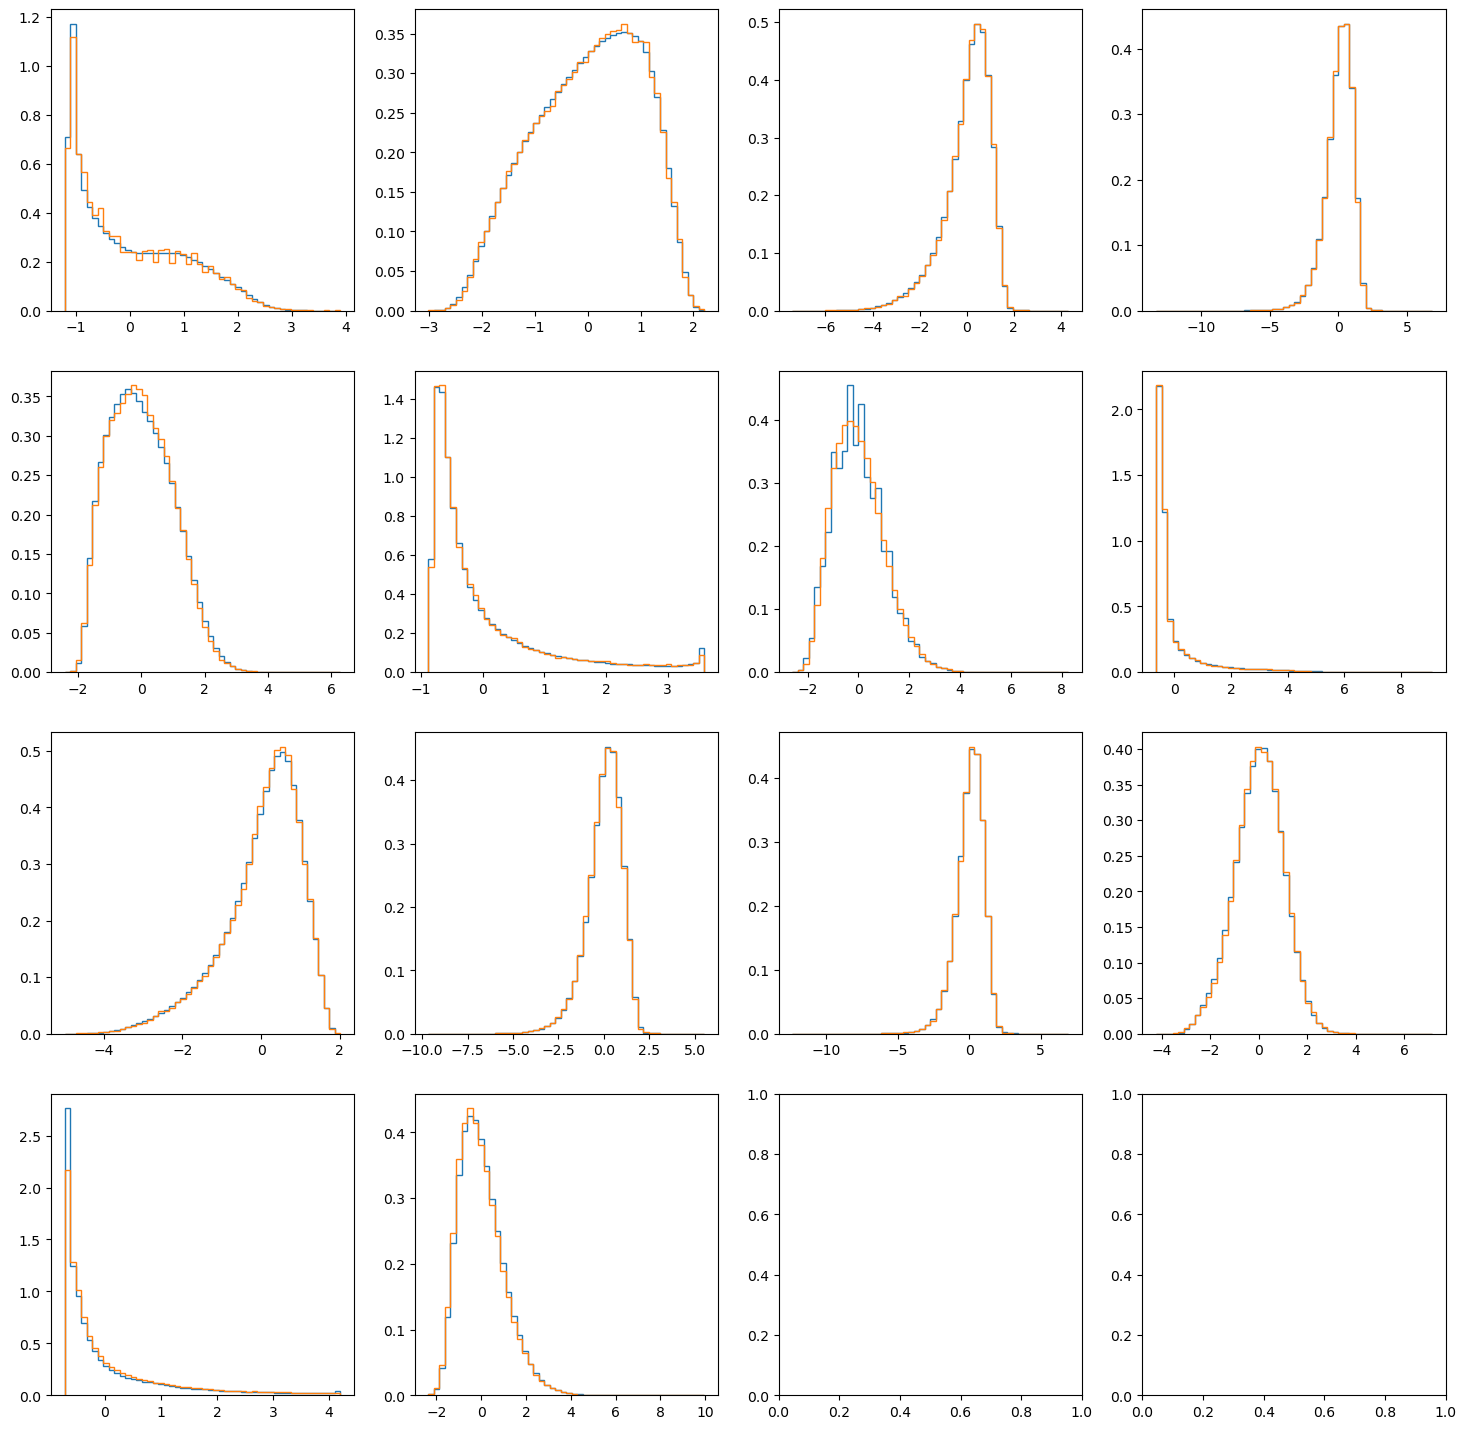

In [28]:
fig,axes = plt.subplots(4,4,figsize=(18,18))
t = axes.flatten()
btest = (bkg_train-test_mean)/test_sd
for i in range(samples.shape[1]):
    plt.sca(t[i])
    h1,bins,_ = plt.hist(btest[:,i],bins=50,histtype='step',density=True)
    h2,bins,_ = plt.hist(samples[:,i],bins=bins,histtype='step',density=True)

In [14]:
s = "XYY3000_Y170_Yp170"
with open(f"combined_trainings/{s}/flow_kwargs.json","r") as f:
    kw = json.load(f)
variables = kw['variables']
flow = make_flow(len(variables),kw).to(device)
flow.load_state_dict(torch.load(f"combined_trainings/{s}/{s}.pt"))
file = signal_merged_dir+signal_map[s]
data = hf.loadData(s,variables,dEta_cut=-1,mode="all")

means = []
stds = []
ref_file = "meanStd.h5" # no dEta cut
with h5py.File(f"input_h5s/BKG/{ref_file}","r") as f:
    for v in variables:
        means.append(f[v+"_mean"][()])
        stds.append(f[v+"_std"][()])
means = np.array(means)
stds = np.array(stds)

with torch.no_grad():
    samples = flow.sample(100000).detach().cpu().numpy()

100%|██████████| 1/1 [00:00<00:00, 71.59it/s]


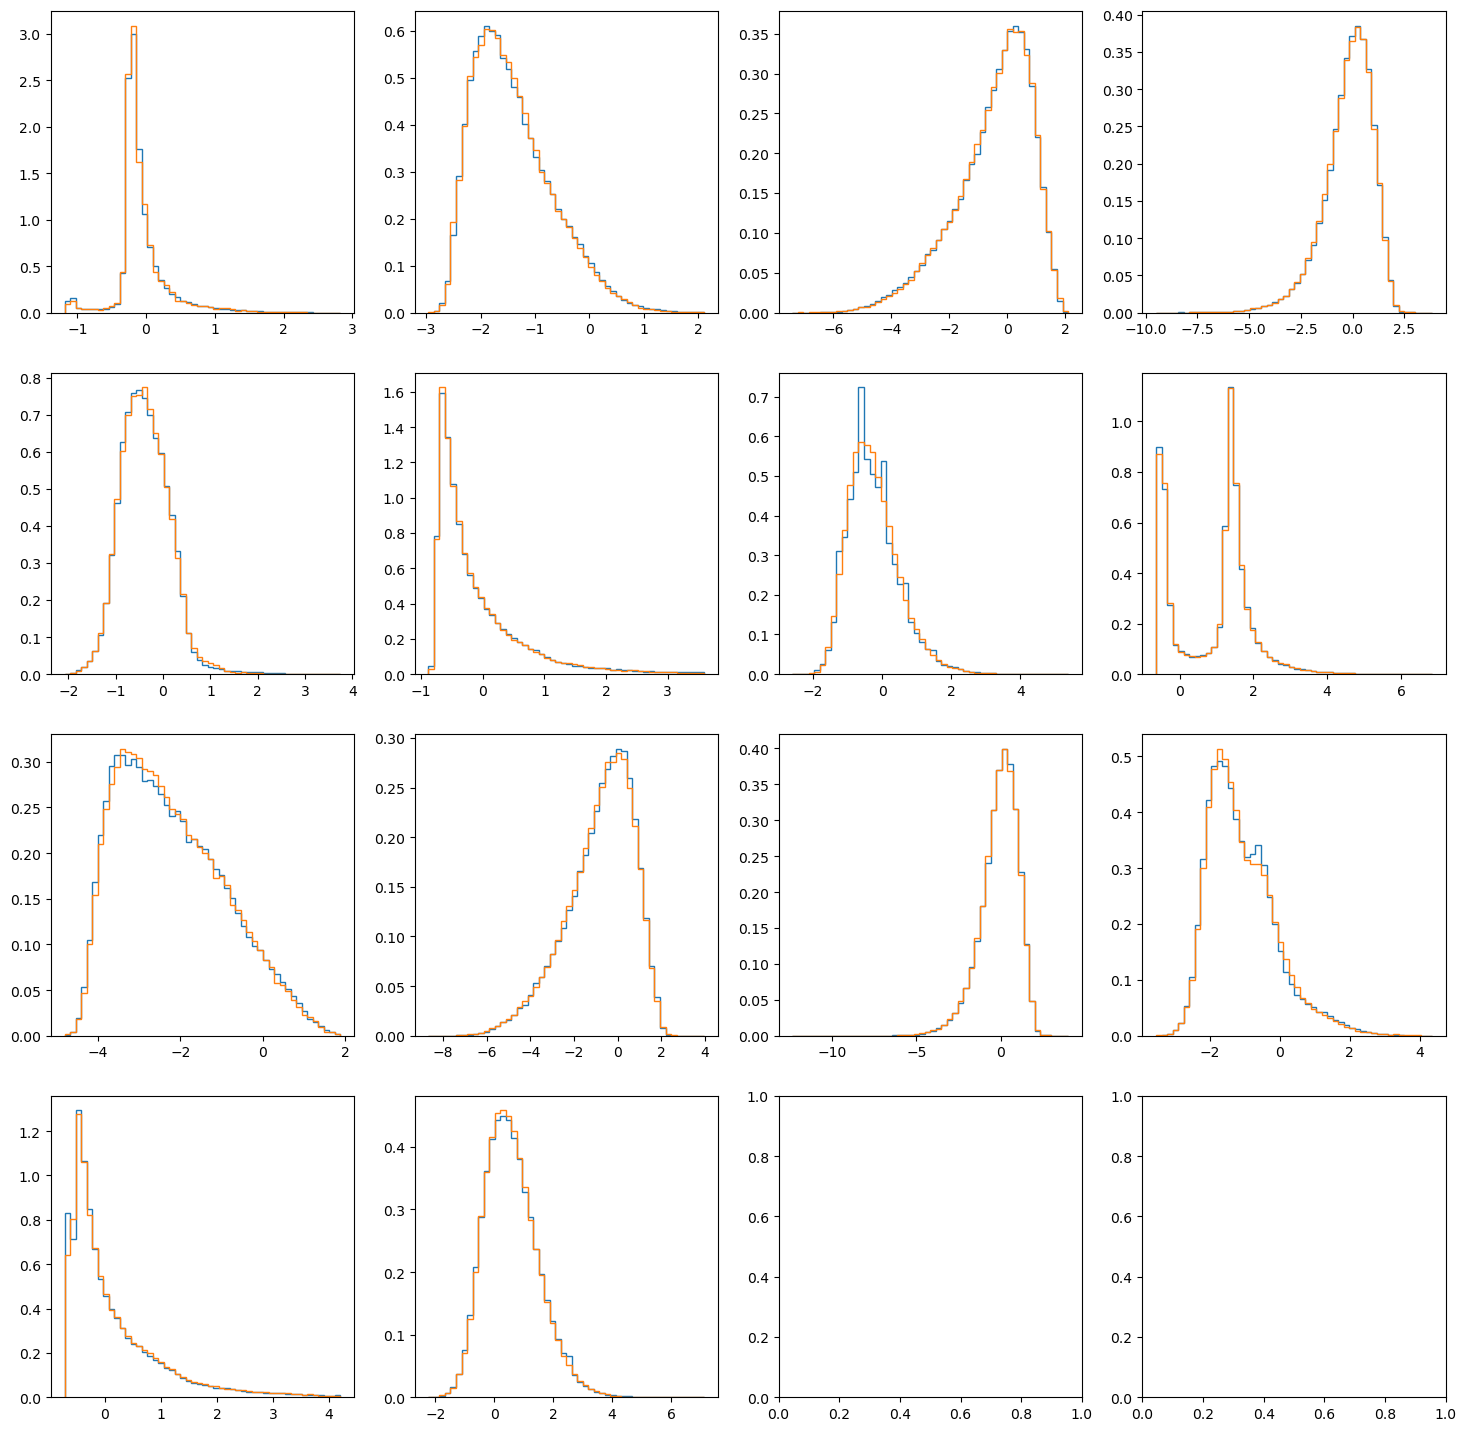

In [16]:
fig,axes = plt.subplots(4,4,figsize=(18,18))
t = axes.flatten()
btest = (data-test_mean)/test_sd
for i in range(samples.shape[1]):
    plt.sca(t[i])
    h1,bins,_ = plt.hist(btest[:,i],bins=50,histtype='step',density=True)
    h2,bins,_ = plt.hist(samples[:,i],bins=bins,histtype='step',density=True)

In [24]:
with h5py.File("input_h5s/BKG/meanStd.h5","r") as fin:
    keys = list(fin.keys())

In [25]:
keys

['dEta_mean',
 'dEta_std',
 'jet1_btagscore_mean',
 'jet1_btagscore_std',
 'jet1_eta_mean',
 'jet1_eta_std',
 'jet1_logTauS_mean',
 'jet1_logTauS_std',
 'jet1_lsf3_mean',
 'jet1_lsf3_std',
 'jet1_mass_mean',
 'jet1_mass_std',
 'jet1_npf_mean',
 'jet1_npf_std',
 'jet1_pb2_mean',
 'jet1_pb2_std',
 'jet1_pb_mean',
 'jet1_pb_std',
 'jet1_phi_mean',
 'jet1_phi_std',
 'jet1_pt_mean',
 'jet1_pt_std',
 'jet1_rho_mean',
 'jet1_rho_std',
 'jet1_tau21_mean',
 'jet1_tau21_std',
 'jet1_tau32_mean',
 'jet1_tau32_std',
 'jet1_tau43_mean',
 'jet1_tau43_std',
 'jet1_tauS_mean',
 'jet1_tauS_std',
 'jet2_btagscore_mean',
 'jet2_btagscore_std',
 'jet2_eta_mean',
 'jet2_eta_std',
 'jet2_logTauS_mean',
 'jet2_logTauS_std',
 'jet2_lsf3_mean',
 'jet2_lsf3_std',
 'jet2_mass_mean',
 'jet2_mass_std',
 'jet2_npf_mean',
 'jet2_npf_std',
 'jet2_pb2_mean',
 'jet2_pb2_std',
 'jet2_pb_mean',
 'jet2_pb_std',
 'jet2_phi_mean',
 'jet2_phi_std',
 'jet2_pt_mean',
 'jet2_pt_std',
 'jet2_rho_mean',
 'jet2_rho_std',
 'jet2_ta

KeyboardInterrupt: 

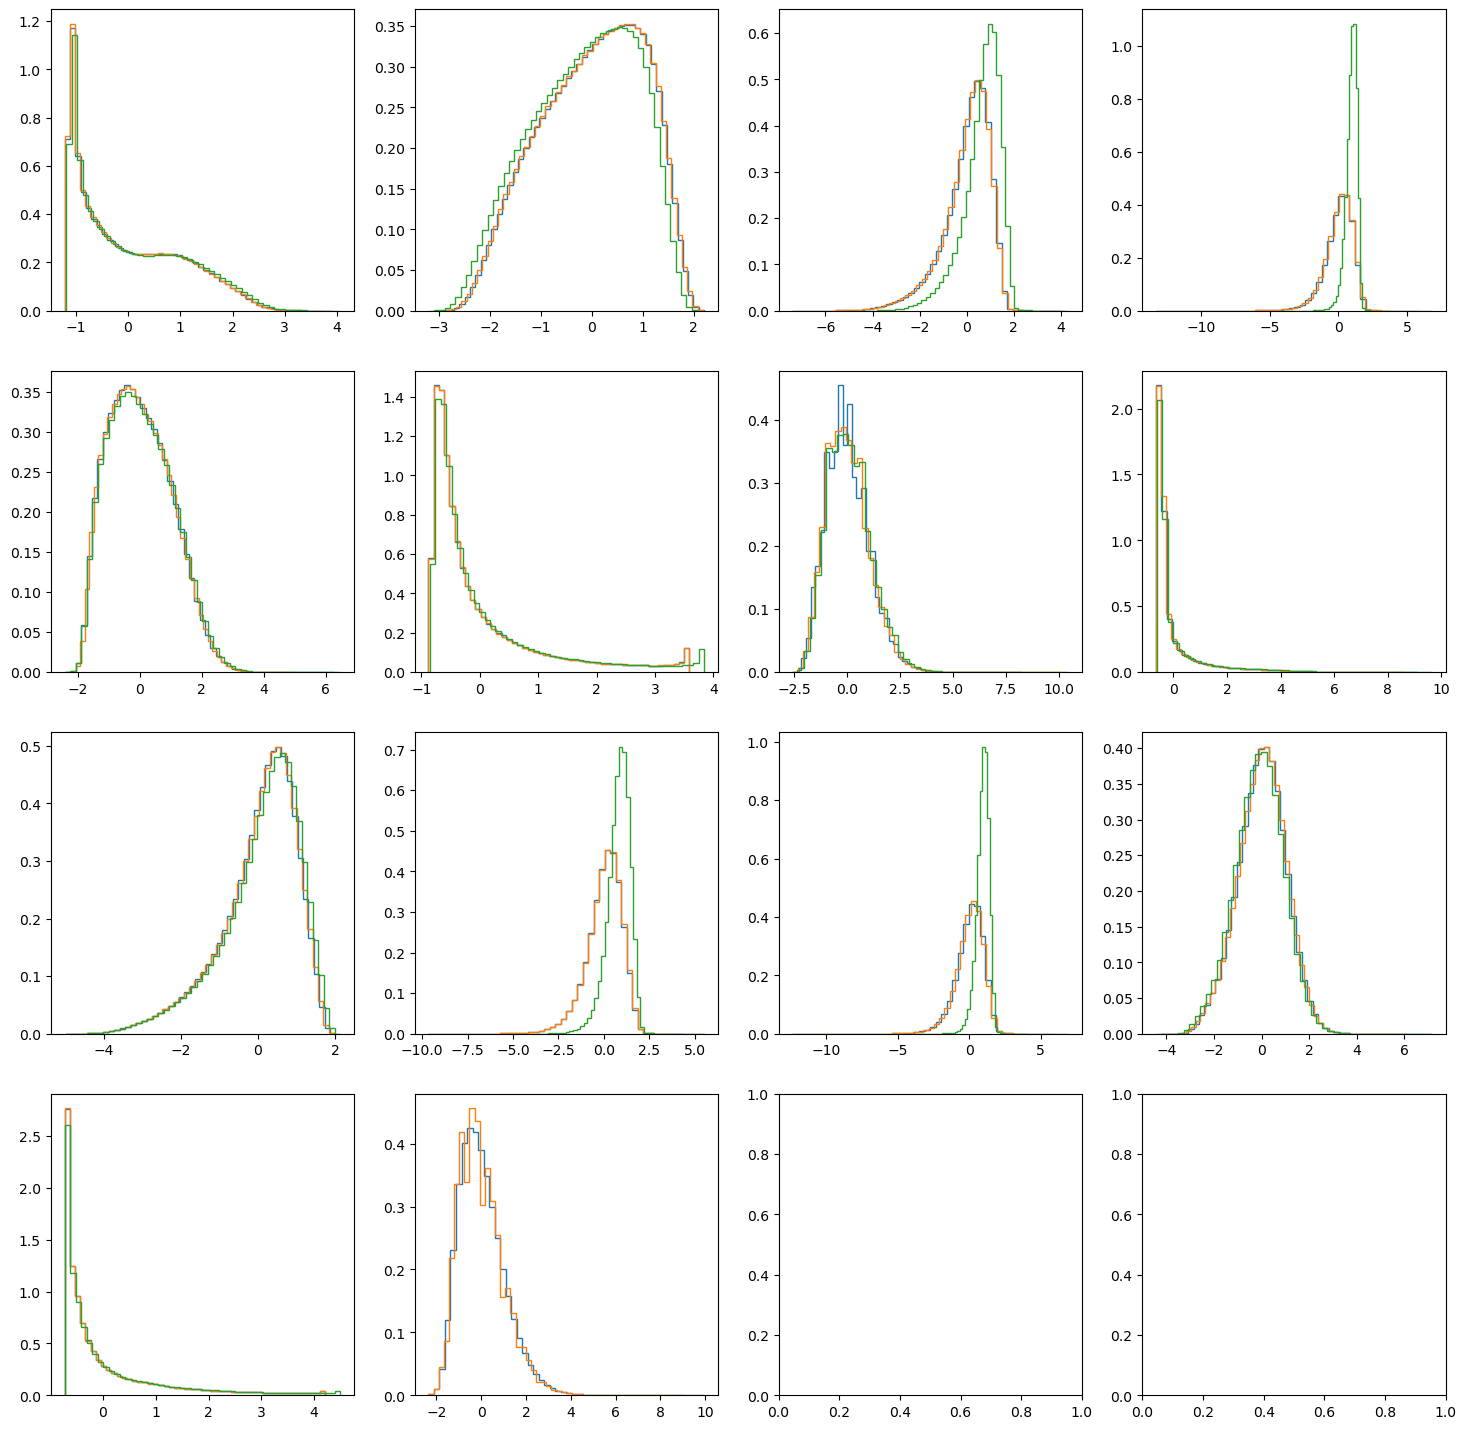

In [29]:
fig,axes = plt.subplots(4,4,figsize=(18,18))
t = axes.flatten()
btest = (data-test_mean)/test_sd
for i in range(samples.shape[1]):
    plt.sca(t[i])
    h1,bins,_ = plt.hist(((bkg_train-test_mean)/test_sd)[:,i],bins=50,histtype='step',density=True)
    h2,bins,_ = plt.hist(((bkg_test-test_mean)/test_sd)[:,i],bins=50,histtype='step',density=True)
    h3,bins,_ = plt.hist(((bkg_all-test_mean)/test_sd)[:,i],bins=50,histtype='step',density=True)

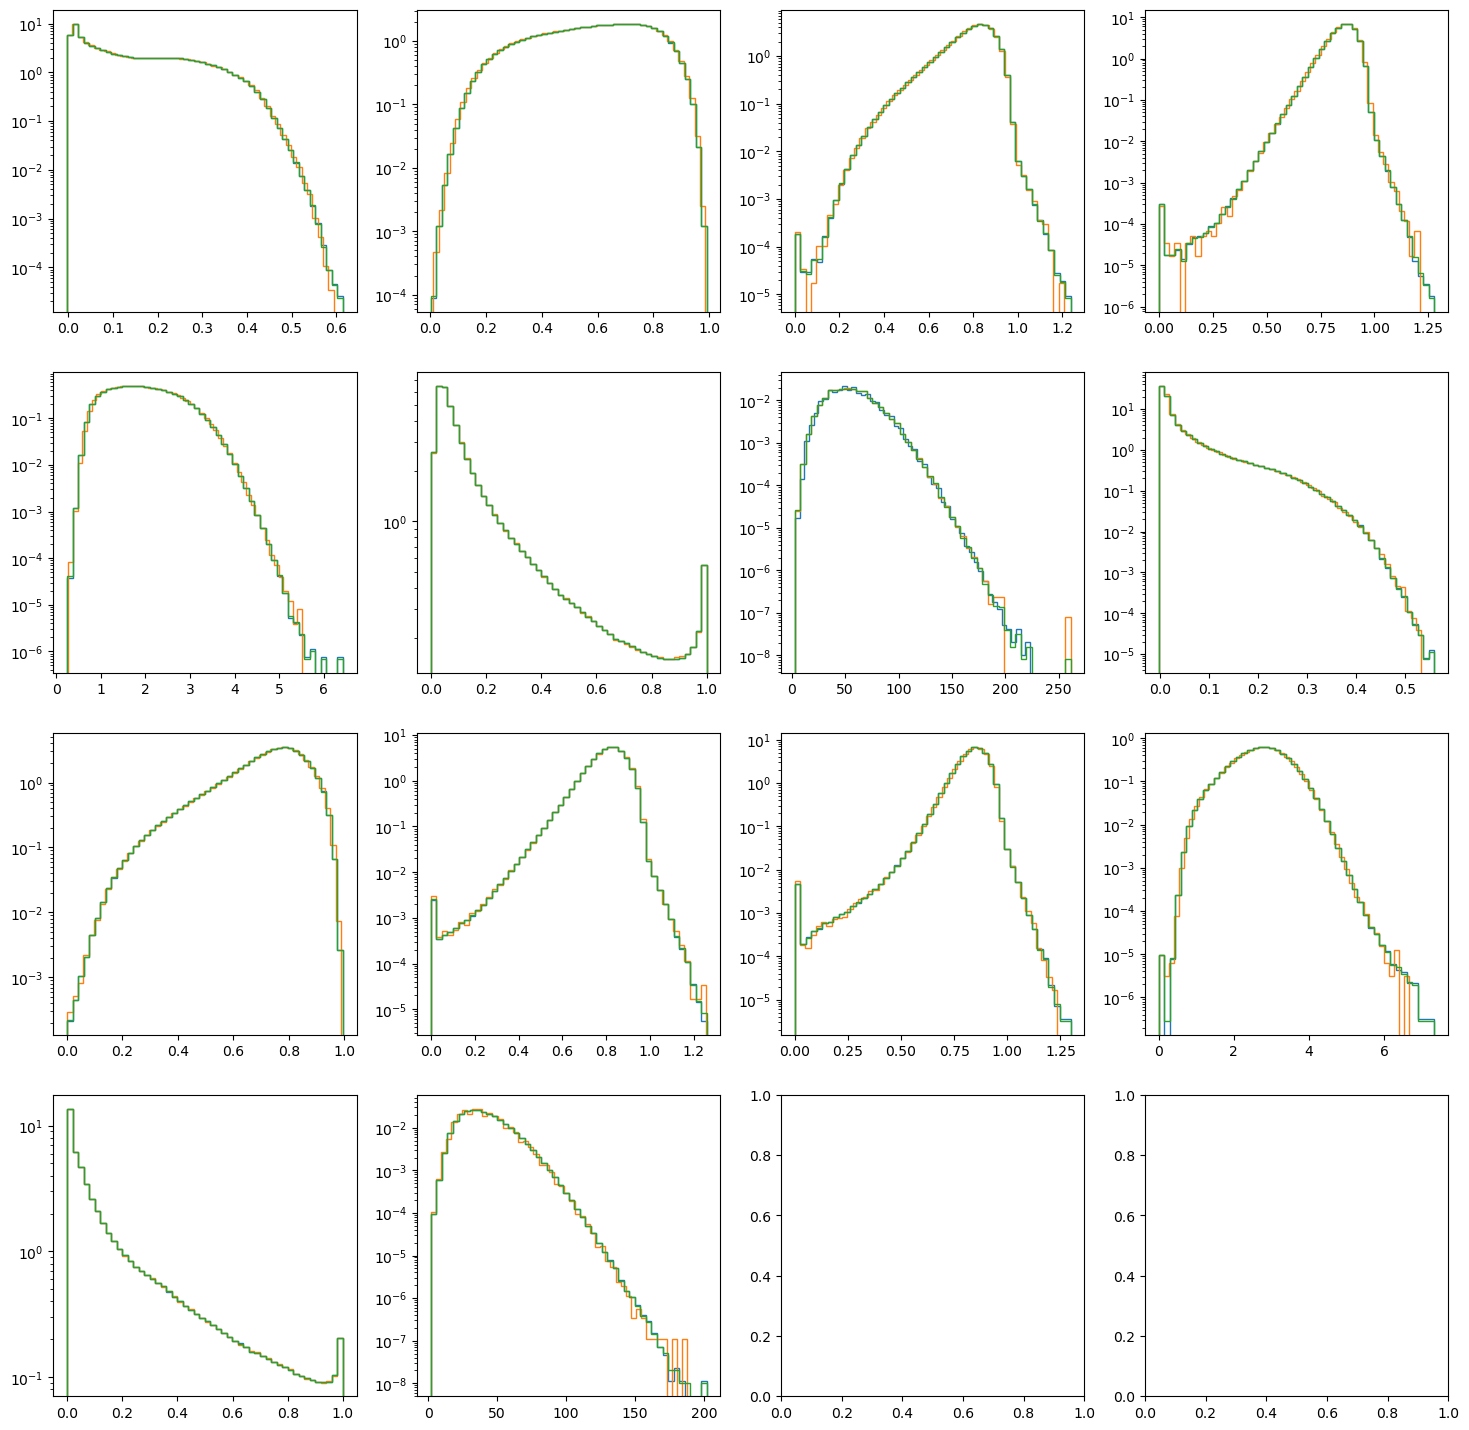

In [23]:
fig,axes = plt.subplots(4,4,figsize=(18,18))
t = axes.flatten()
btest = (data-test_mean)/test_sd
for i in range(samples.shape[1]):
    plt.sca(t[i])
    h1,bins,_ = plt.hist(bkg_train[:,i],bins=50,histtype='step',density=True)
    h2,bins,_ = plt.hist(bkg_test[:,i],bins=50,histtype='step',density=True)
    h3,bins,_ = plt.hist(bkg_all[:,i],bins=50,histtype='step',density=True)
    plt.yscale('log')

# Compare training data with corresponnding flow samples

In [3]:
variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
means = []
stds = []
ref_file = "meanStd.h5" # no dEta cut
with h5py.File(f"input_h5s/BKG/{ref_file}","r") as f:
    for v in variables:
        means.append(f[v+"_mean"][()])
        stds.append(f[v+"_std"][()])
means = np.array(means)
stds = np.array(stds)

In [10]:
trainings = [t for t in os.listdir('combined_trainings') if "DATA" not in t and t != '.ipynb_checkpoints' and t != 'BKG' and 'RSG' not in t]
from samples import daughterGroups_2and3TeV, topologyGroups_heavyDaughters, signal_map
all_samps = {**signal_map,**daughterGroups_2and3TeV,**topologyGroups_heavyDaughters}

In [11]:
for i in range(len(trainings)):
    s = trainings[i]
    if s in all_samps.keys() and type(all_samps[s]) == list:
        sample = all_samps[s]
    else:
        sample = s
    

    mode = 'test'
    nevts = 100000
    if type(sample) == list:
        datas = []
        nev_per = int(nevts/len(sample))
        for samp in sample:
            datas.append(hf.loadData(samp,variables,nMax=nev_per,mode=mode,
                                     dEta_cut=-1,sideband=False))
        data = np.concatenate(datas,axis=0)
        np.random.shuffle(data)
    else:
        data = hf.loadData(sample,variables,nMax=nevts,mode=mode,dEta_cut=-1,sideband=False)
    data = (data-means)/stds


    with open(f"combined_trainings/{s}/flow_kwargs.json","r") as f:
        kw = json.load(f)
    variables = kw['variables']
    flow = make_flow(len(variables),kw).to(device)
    flow.load_state_dict(torch.load(f"combined_trainings/{s}/{s}.pt"))

    with torch.no_grad():
        samples = flow.sample(100000).detach().cpu().numpy()
    del flow 
    torch.cuda.empty_cache()
    
    fig,axes = plt.subplots(4,4,figsize=(18,18))
    t = axes.flatten()
    for i in range(data.shape[1]):
        plt.sca(t[i])
        h1,bins,_ = plt.hist(data[:,i],bins=50,histtype='step',density=True)
        h2,bins,_ = plt.hist(samples[:,i],bins=bins,histtype='step',density=True)
        plt.xlabel(variables[i],fontsize=14)
    plt.suptitle(s,fontsize=16)
    plt.tight_layout()
    plt.savefig(f"trainBug_investigation/flowSamples_vs_truth/samples_{s}.png")
    plt.close()
    del samples, data

100%|██████████| 1/1 [00:00<00:00,  2.07it/s]


# look at specific losses

In [2]:
from samples import daughterGroups_2and3TeV, topologyGroups_heavyDaughters, signal_map
trainings = list(daughterGroups_2and3TeV.keys())
samples_xyy = [s for s in signal_map.keys() if "XYY" in s]

variables = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43','jet1_logTauS','jet1_pb','jet1_npf',
             'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43','jet2_logTauS','jet2_pb','jet2_npf']
ref_file = "meanStd.h5" # no dEta cut
means = []
stds = []
with h5py.File(f"input_h5s/BKG/{ref_file}","r") as f:
    for v in variables:
        means.append(f[v+"_mean"][()])
        stds.append(f[v+"_std"][()])
means = np.array(means)
stds = np.array(stds)

In [6]:
for samp in samples_xyy:
    data_inc = hf.loadData(samp,variables,nMax=100000,mode='all',dEta_cut=-1,sideband=False)
    data_sr = hf.loadData(samp,variables,nMax=100000,mode='all',dEta_cut=1.3,sideband=False)
    data_inc = (data_inc-means)/stds
    data_sr = (data_sr-means)/stds
    
    fig,axes = plt.subplots(2,5,figsize=(20,8))
    t = axes.flatten()
    for j,mod in enumerate(trainings):
        with open(f"combined_trainings/{mod}/flow_kwargs.json","r") as f:
            kw = json.load(f)
        variables = kw['variables']
        flow = make_flow(len(variables),kw).to(device)
        flow.load_state_dict(torch.load(f"combined_trainings/{mod}/{mod}.pt"))

        with torch.no_grad():
            loss_inc = -flow.log_prob(torch.tensor(data_inc,device=device,dtype=torch.float32))[0].detach().cpu().numpy()
            loss_sr = -flow.log_prob(torch.tensor(data_sr,device=device,dtype=torch.float32))[0].detach().cpu().numpy()
        del flow 
        torch.cuda.empty_cache()

        with h5py.File(f"lossEvals/{samp}.h5","r") as f:
            loss_write = f[mod][()]
        
        plt.sca(t[j])
        h1,bins,_ = plt.hist(loss_inc,bins=50,histtype='step',density=True,label='inclusive')
        h2,bins,_ = plt.hist(loss_sr,bins=bins,histtype='step',density=True,label='sr')
        h3,bins,_ = plt.hist(loss_write,bins=bins,histtype='step',density=True,label='file')
        plt.xlabel('loss')
        plt.title(mod)
        plt.yscale('log')
        plt.legend()
        
        del loss_inc, loss_sr, loss_write
        torch.cuda.empty_cache()
    plt.suptitle(samp,fontsize=16)
    plt.tight_layout()
    plt.savefig(f"trainBug_investigation/lossEval_plots/massBinTrainings_{samp}.png")
    plt.close()
    del data_inc, data_sr
    torch.cuda.empty_cache()

100%|██████████| 1/1 [00:00<00:00,  5.27it/s]


In [28]:
xyy3 = ["XYY3000_Y170_Yp170","XYY3000_Y25_Yp25","XYY3000_Y400_Yp400"]
from samples import daughterGroups_2and3TeV, topologyGroups_heavyDaughters, signal_map
trainings = list(daughterGroups_2and3TeV.keys())

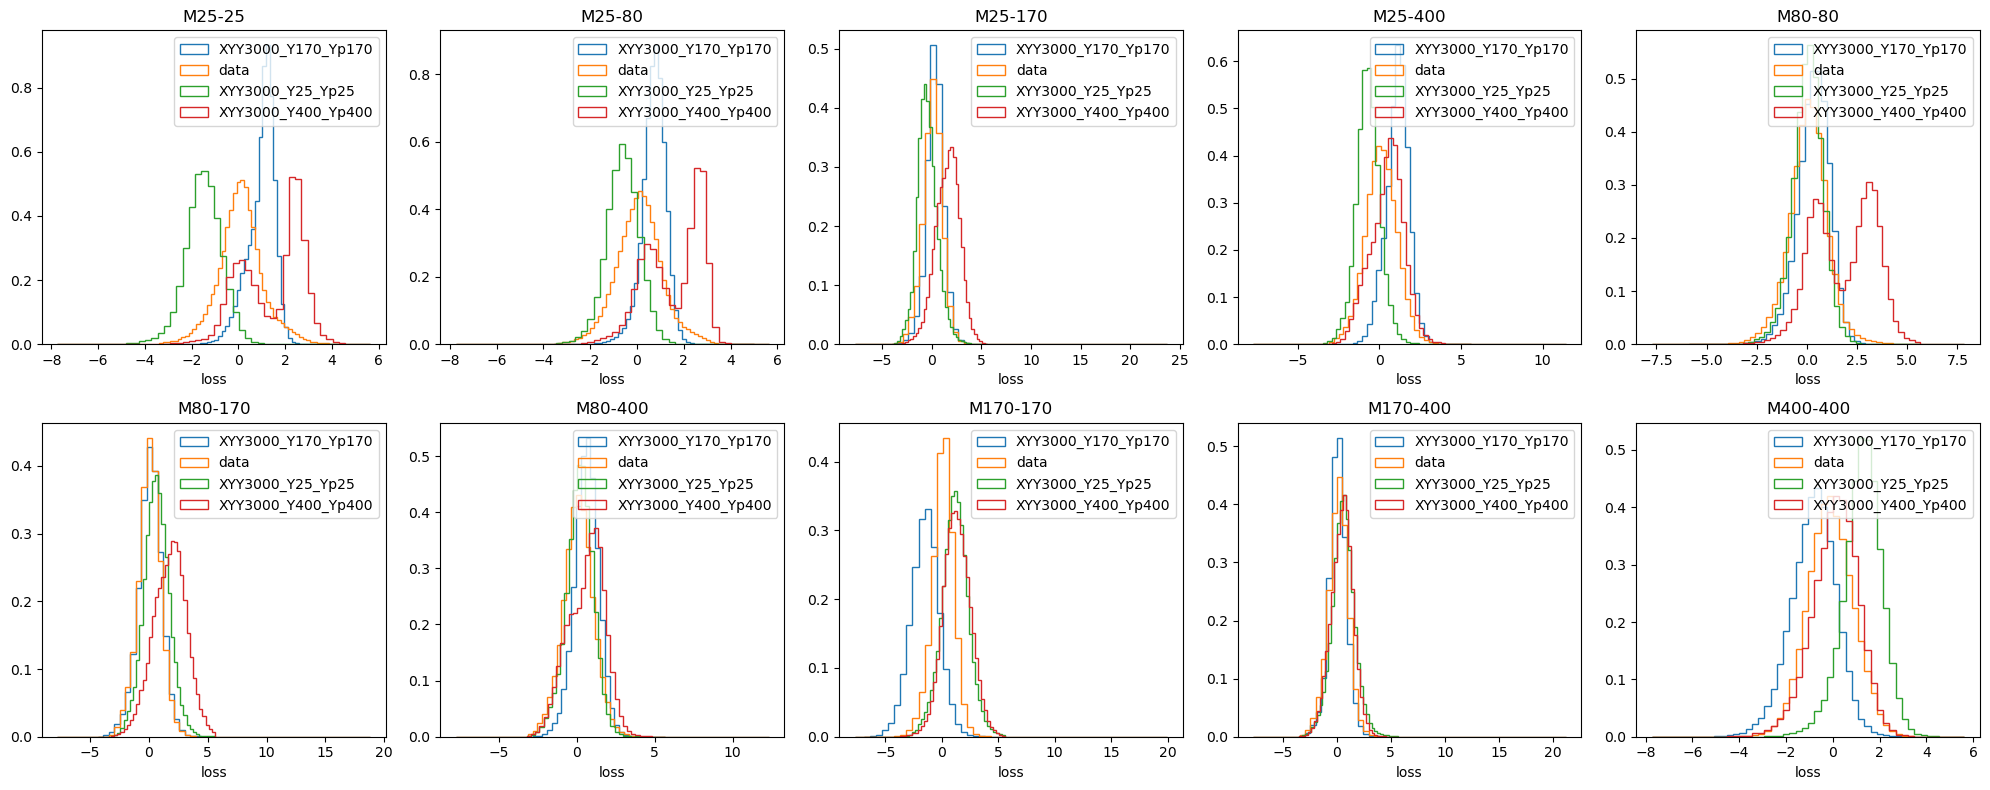

In [30]:
fig,axes = plt.subplots(2,5,figsize=(20,8))
t = axes.flatten()
for i,samp in enumerate(xyy3):
    for j,mod in enumerate(trainings):
        with h5py.File(f"lossEvals_pcaDecorr_boxCox/{samp}.h5","r") as f:
            loss_sig = f[mod][()]
        plt.sca(t[j])
        if i==0:
            h1,bins,_ = plt.hist(loss_sig,bins=50,histtype='step',density=True,label=samp)
            with h5py.File(f"lossEvals_pcaDecorr_boxCox/DATA.h5","r") as f:
                loss_dat = f[mod][:100000]
            h2,bins,_ = plt.hist(loss_dat,bins=bins,histtype='step',density=True,label='data')
            del loss_sig, loss_dat
        else:
            h1,bins,_ = plt.hist(loss_sig,bins=bins,histtype='step',density=True,label=samp)
            del loss_sig
        plt.title(mod)
for i in range(len(t)):
    plt.sca(t[i])
    plt.xlabel('loss')
    #plt.yscale('log')
    plt.legend()
plt.tight_layout()
plt.savefig(f"trainBug_investigation/lossEval_pcaDecorr_boxCox_plots/xyy3000_vs_data_massAxes_comparison.png")
#plt.close()

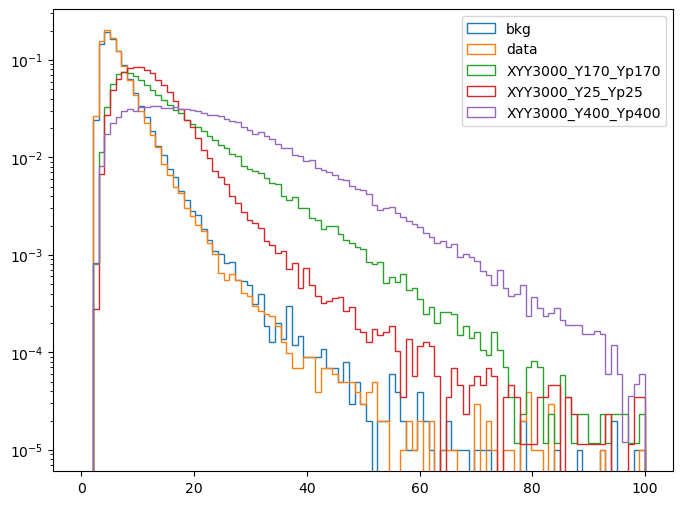

In [31]:
data = []
for mod in trainings:
    with h5py.File(f"lossEvals_pcaDecorr_boxCox/DATA.h5","r") as f:
        data.append(f[mod][:100000].reshape(-1,1))
data = np.concatenate(data,axis=1)

bkg = []
for mod in trainings:
    with h5py.File(f"lossEvals_pcaDecorr_boxCox/BKG.h5","r") as f:
        bkg.append(f[mod][:100000].reshape(-1,1))
bkg = np.concatenate(bkg,axis=1)

sigs = {s:[] for s in xyy3}
for i,samp in enumerate(xyy3):
    for j,mod in enumerate(trainings):
        with h5py.File(f"lossEvals_pcaDecorr_boxCox/{samp}.h5","r") as f:
            sigs[samp].append(f[mod][()].reshape(-1,1))
    sigs[samp] = np.concatenate(sigs[samp],axis=1)

cov = np.cov(bkg,rowvar=False)
mean = bkg.mean(axis=0)
from scipy.stats import multivariate_normal as mvn
pdf = mvn(mean=mean,cov=cov)
bkg_loss = -pdf.logpdf(bkg)
data_loss = -pdf.logpdf(data)
sig_loss = {s:-pdf.logpdf(sigs[s]) for s in sigs.keys()}
plt.figure(figsize=(8,6))
bins = np.linspace(0,100,100)
h1,bins,_ = plt.hist(bkg_loss,bins=bins,density=True,histtype='step',label='bkg')
h1,bins,_ = plt.hist(data_loss,bins=bins,density=True,histtype='step',label='data')
for s in sig_loss.keys():
    h1,bins,_ = plt.hist(sig_loss[s],bins=bins,density=True,histtype='step',label=s)
plt.yscale('log')
plt.legend(loc='upper right')

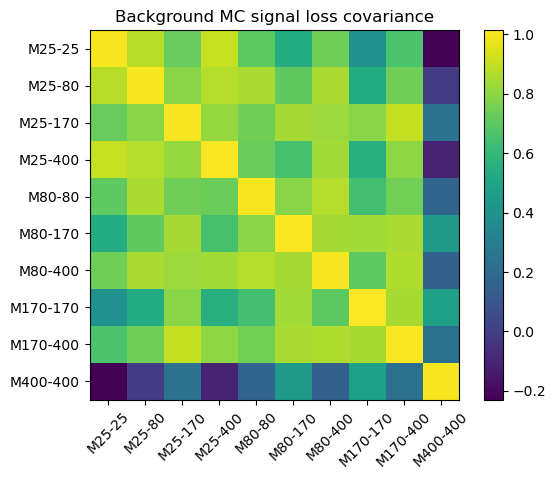

In [32]:
plt.imshow(cov)
plt.xticks(np.arange(10),trainings,rotation=45)
yt=plt.yticks(np.arange(10),trainings,rotation=0)
plt.title("Background MC signal loss covariance")
plt.colorbar()

In [33]:
from scipy.stats import boxcox
bkg_loss_bc, lmd = boxcox(bkg_loss)
bm = bkg_loss_bc.mean(axis=0)
bstd = bkg_loss_bc.std(axis=0)
bkg_loss_bc = (bkg_loss_bc-bm)/bstd

data_loss_bc = (boxcox(data_loss,lmbda=lmd)-bm)/bstd
sig_loss_bc = {}
for samp in sig_loss.keys():
    sig_loss_bc[samp] = (boxcox(sig_loss[samp],lmbda=lmd)-bm)/bstd

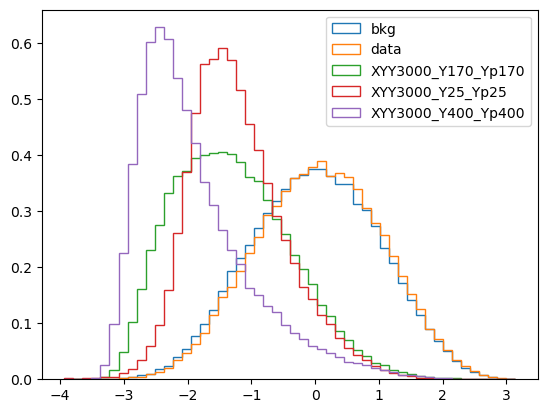

In [36]:
h1,bins,_ = plt.hist(-bkg_loss_bc,bins=50,density=True,histtype='step',label='bkg')
h1,bins,_ = plt.hist(-data_loss_bc,bins=bins,density=True,histtype='step',label='data')
for s in sig_loss.keys():
    h1,bins,_ = plt.hist(-sig_loss_bc[s],bins=bins,density=True,histtype='step',label=s)
#plt.yscale('log')
plt.legend(loc='upper right')

In [117]:
sig_bloss = {s:[] for s in xyy3}
for i,samp in enumerate(xyy3):
    with h5py.File(f"lossEvals_pcaDecorr_boxCox/{samp}.h5","r") as f:
        sig_bloss[samp] = f['BKG_mjjFlat'][()]
with h5py.File(f"lossEvals_pcaDecorr_boxCox/DATA.h5","r") as f:
    dat_bloss = f["BKG_mjjFlat"][:100000]

(-5.0, 5.0)

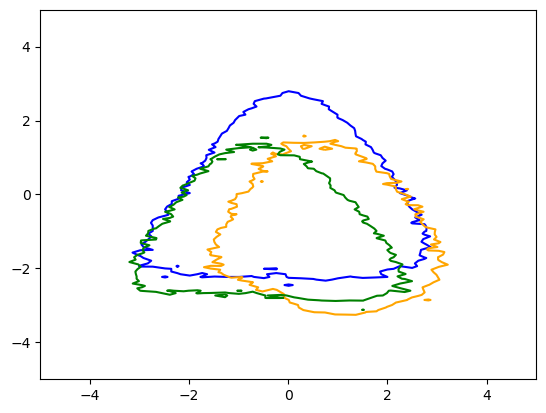

In [121]:
from matplotlib.colors import LogNorm
def do_contour(xd,yd,bx=100,by=100,clevel=[0.0001],colors=['blue']):  
    zd,xbins,ybins = np.histogram2d(xd,yd,bins=(bx,by))
    ntot = xd.shape[0]
    zd /= ntot
    plt.contour(zd.T,extent=[xbins.min(),xbins.max(),ybins.min(),ybins.max()],levels=clevel,colors=colors)
do_contour(dat_bloss,-data_loss_bc,colors=['blue'])
scols = ['orange','green']
for i,s in enumerate(list(sig_bloss.keys())):
    do_contour(sig_bloss[s],-sig_loss_bc[s],colors=scols[i])
plt.ylim([-5,5])
plt.xlim([-5,5])

# calculate gaussian reduction of mass-binned losses for all signals

In [123]:
from samples import daughterGroups_2and3TeV
from scipy.stats import boxcox
from scipy.stats import multivariate_normal as mvn

trainings = list(daughterGroups_2and3TeV.keys())
samples = [s for s in os.listdir("lossEvals_pcaDecorr_boxCox/") if ".h5" in s]

# load losses for bkg
bkg = []
for mod in trainings:
    with h5py.File(f"lossEvals_pcaDecorr_boxCox/BKG.h5","r") as f:
        bkg.append(f[mod][()].reshape(-1,1))
bkg = np.concatenate(bkg,axis=1)

# get mean/cov for gaussian
cov = np.cov(bkg,rowvar=False)
mean = bkg.mean(axis=0)
from scipy.stats import multivariate_normal as mvn
pdf = mvn(mean=mean,cov=cov)

# eval gaussian logprob on bkg, do boxcox
bkg_loss = -pdf.logpdf(bkg)
bkg_loss_bc, lam = boxcox(bkg_loss)
bcmean = bkg_loss_bc.mean(axis=0)
bcstd = bkg_loss_bc.std(axis=0)

del bkg_loss, bkg_loss_bc

In [136]:
# Loop over files and write new losses
from tqdm import tqdm
for samp in tqdm(samples):
    with h5py.File(f"lossEvals_pcaDecorr_boxCox/{samp}","r") as f:
        losses = []
        for t in trainings:
            losses.append(f[t][()].reshape(-1,1))
        losses = np.concatenate(losses,axis=1)
    losses = -pdf.logpdf(losses)
    losses = boxcox(losses,lmbda=lam)
    losses = (losses-bcmean)/bcstd
    with h5py.File(f"lossEvals_pcaDecorr_boxCox/{samp}","r+") as f:
        f.create_dataset("Mbinned_all_gausReduction",data=-losses)

100%|██████████| 91/91 [01:47<00:00,  1.18s/it]


In [2]:
# look at spaces
from scipy.stats import norm
with h5py.File(f"lossEvals_pcaDecorr_boxCox/BKG.h5","r") as f:
    bkg_lb = f['BKG_mjjFlat'][()]
mean_lb = bkg_lb.mean()
std_lb = bkg_lb.std()
mlogp_lb = -norm.logpdf(bkg_lb,loc=mean_lb,scale=std_lb)
mean_mlogp = mlogp_lb.mean()
std_mlogp = mlogp_lb.std()

In [10]:
with h5py.File(f"lossEvals_pcaDecorr_boxCox/DATA.h5","r") as f:
    data_lb = f['BKG_mjjFlat'][()]
    data_lsig = f['Mbinned_all_gausReduction'][()]
#data_lb = -norm.logpdf(data_lb,loc=mean_lb,scale=std_lb)
#data_lb = (data_lb-mean_mlogp)/std_mlogp

In [11]:
def plot_samp(samp,data_lb,data_lsig):
    with h5py.File(f"lossEvals_pcaDecorr_boxCox/{samp}.h5","r") as f:
        sig_lb = f['BKG_mjjFlat'][()]
        sig_lsig = f['Mbinned_all_gausReduction'][()]
    
    #sig_lb = -norm.logpdf(sig_lb,loc=mean_lb,scale=std_lb)
    #sig_lb = (sig_lb-mean_mlogp)/std_mlogp
    bx = np.linspace(-5,6,50)
    by = np.linspace(-5,5,50)
    from matplotlib.colors import LogNorm
    plt.figure(figsize=(10,5))
    plt.subplot(121)
    plt.hist2d(data_lb,data_lsig,bins=(bx,by),density=True,norm=LogNorm())
    plt.title("Data")
    plt.text(-4,4,f"Mean = ({data_lb.mean():.3f},{data_lsig.mean():.3f})")
    plt.subplot(122)
    plt.hist2d(sig_lb,sig_lsig,bins=(bx,by),density=True,norm=LogNorm())
    plt.title(samp)
    plt.text(-4,4,f"Mean = ({sig_lb.mean():.3f},{sig_lsig.mean():.3f})")

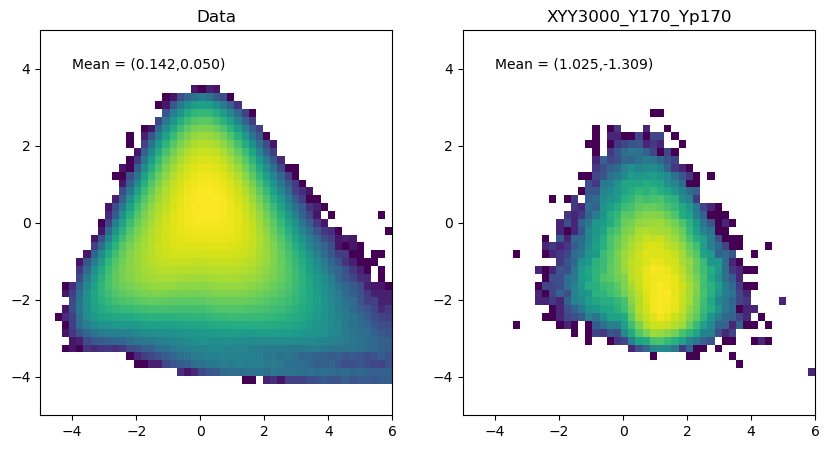

In [12]:
plot_samp("XYY3000_Y170_Yp170",data_lb,data_lsig)

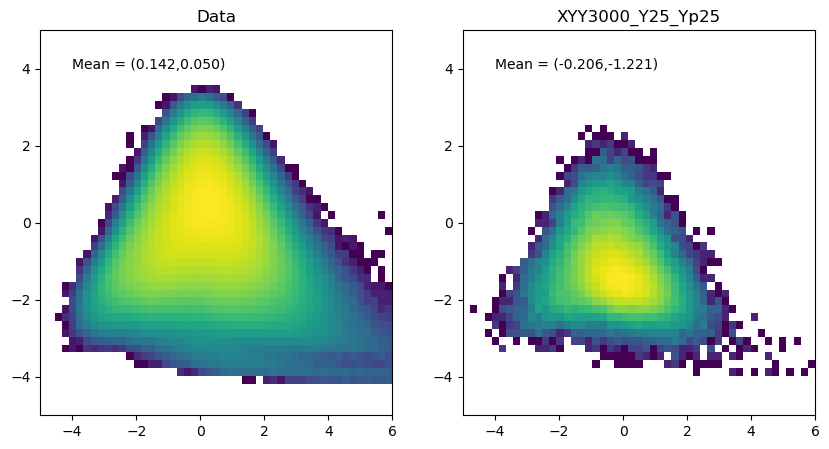

In [13]:
plot_samp("XYY3000_Y25_Yp25",data_lb,data_lsig)

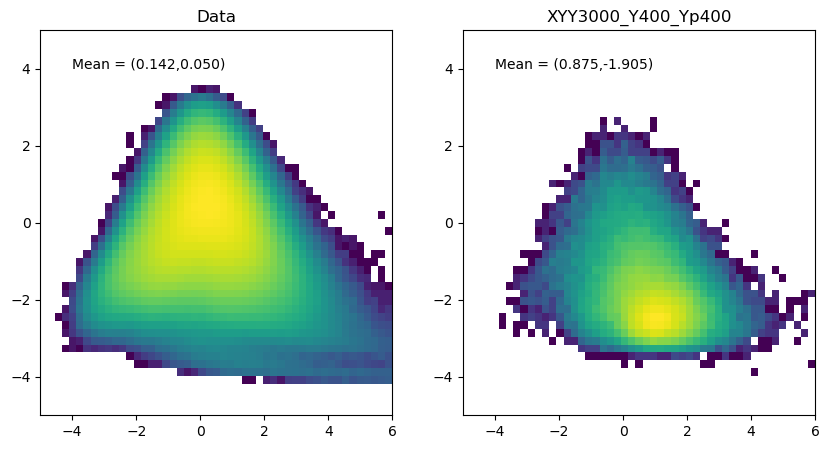

In [14]:
plot_samp("XYY3000_Y400_Yp400",data_lb,data_lsig)